In [ ]:
import requests
from bs4 import BeautifulSoup

url = "https://companiesmarketcap.com/e-commerce/largest-e-commerce-companies-by-number-of-employees/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")


Table

In [ ]:
rows = soup.find_all("tr")
data = []

for row in rows[1:]:   # skip header
    cols = row.find_all("td")
    # Based on inspection of the page structure for employee data:
    # cols[0] is often an empty <td>
    # cols[1] contains the rank
    # cols[2] contains the company name
    # cols[3] contains the employee count
    if len(cols) >= 4:  # Ensure there are enough columns to access indices 1, 2, and 3
        rank = cols[1].text.strip()
        company = cols[2].text.strip()
        employees_count = cols[3].text.strip()
        data.append([rank, company, employees_count])

# Example: print first 5 rows
for d in data[:5]:
    print(d)

['1', 'AmazonAMZN', '1,546,000']
['2', 'JD.comJD', '900,000']
['3', 'AlibabaBABA', '123,711']
['4', 'Meituan3690.HK', '114,731']
['5', 'CoupangCPNG', '95,000']


Head Top Tables

In [ ]:
import pandas as pd
df = pd.DataFrame(data, columns=['Rank', 'Company', 'Employees'])
df.head(5)

,Rank,Company,Employees
0,1,AmazonAMZN,"1,546,000"
1,2,JD.comJD,"900,000"
2,3,AlibabaBABA,"123,711"
3,4,Meituan3690.HK,"114,731"
4,5,CoupangCPNG,"95,000"


Cleaning tables by using Drop Method

In [ ]:
df_clean = df.dropna()


Filters

In [ ]:
df_filtered = df[df["Employees"] != "N/A"]


In [ ]:
rows = soup.find_all("tr")
data = []

for row in rows[1:]:   # skip header
    cols = row.find_all("td")
    # Based on inspection of the page structure for employee data:
    # cols[0] is often an empty <td>
    # cols[1] contains the rank
    # cols[2] contains the company name
    # cols[3] contains the employee count
    if len(cols) >= 4:  # Ensure there are enough columns to access indices 1, 2, and 3
        rank = cols[1].text.strip()
        company = cols[2].text.strip()
        employees_count = cols[3].text.strip()
        data.append([rank, company, employees_count])

# Example: print first 5 rows
for d in data[:5]:
    print(d)

['1', 'AmazonAMZN', '1,546,000']
['2', 'JD.comJD', '900,000']
['3', 'AlibabaBABA', '123,711']
['4', 'Meituan3690.HK', '114,731']
['5', 'CoupangCPNG', '95,000']


Top 10 and Highest Valued E Commerce Companies By Employees

/tmp/ipython-input-830/1887679136.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Company", y="Employees", data=top10, palette="viridis")


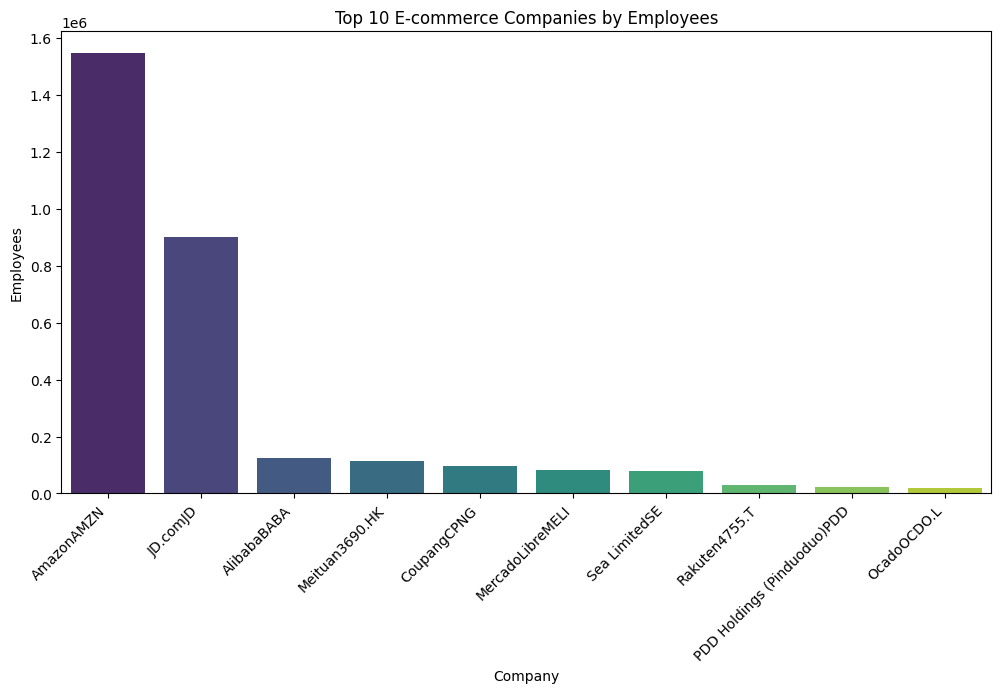

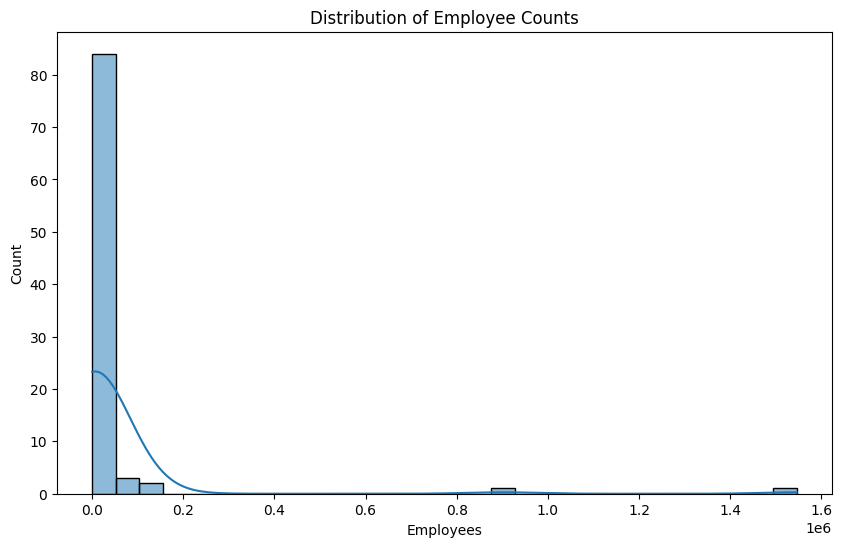

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a working copy to modify
plot_df = df.copy()

# Clean and convert 'Employees' column to numeric
# Ensure 'Employees' column is string type before applying string methods
# This handles cases where 'Employees' might already be numeric from a prior execution
plot_df['Employees'] = plot_df['Employees'].astype(str)

# It contains commas and might contain 'N/A' or other non-numeric values
plot_df['Employees'] = plot_df['Employees'].str.replace(',', '', regex=False)
plot_df['Employees'] = pd.to_numeric(plot_df['Employees'], errors='coerce')
plot_df.dropna(subset=['Employees'], inplace=True);
plot_df['Employees'] = plot_df['Employees'].astype(int)

# Top 10 companies by employees
top10 = plot_df.nlargest(10, "Employees")
plt.figure(figsize=(12,6))
sns.barplot(x="Company", y="Employees", data=top10, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 E-commerce Companies by Employees")
plt.show()

# Distribution of employees
plt.figure(figsize=(10,6))
sns.histplot(plot_df["Employees"], bins=30, kde=True)
plt.title("Distribution of Employee Counts")
plt.show()

Top 5

In [ ]:
# Top 5 companies by number of employees
# We can reuse the 'plot_df' created earlier, which already has 'Employees' as an integer type.
top5_employees = plot_df.nlargest(5, "Employees")
# The 'Country' column does not exist in the DataFrame. Removed it from the print statement.
print(top5_employees[["Company", "Employees"]])

          Company  Employees
0      AmazonAMZN    1546000
1        JD.comJD     900000
2     AlibabaBABA     123711
3  Meituan3690.HK     114731
4     CoupangCPNG      95000


Outliers

In [ ]:
# Identify outliers using the Interquartile Range (IQR) method for Employees
Q1 = df['Employees'].quantile(0.25)
Q3 = df['Employees'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Employees'] < lower_bound) | (df['Employees'] > upper_bound)]

print(f"Number of outliers detected: {len(outliers)}")
print("\nOutliers based on Employees:")
display(outliers)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)


Number of outliers detected: 17

Outliers based on Employees:


,Rank,Company,Employees
0,1,AmazonAMZN,1546000.0
1,2,JD.comJD,900000.0
2,3,AlibabaBABA,123711.0
3,4,Meituan3690.HK,114731.0
4,5,CoupangCPNG,95000.0
5,6,MercadoLibreMELI,84207.0
6,7,Sea LimitedSE,80700.0
7,8,Rakuten4755.T,29334.0
8,9,PDD Holdings (Pinduoduo)PDD,23465.0
9,10,OcadoOCDO.L,20261.0


Lower Bound: -6764.25
Upper Bound: 12905.75


K Means For Unsupervised Learning

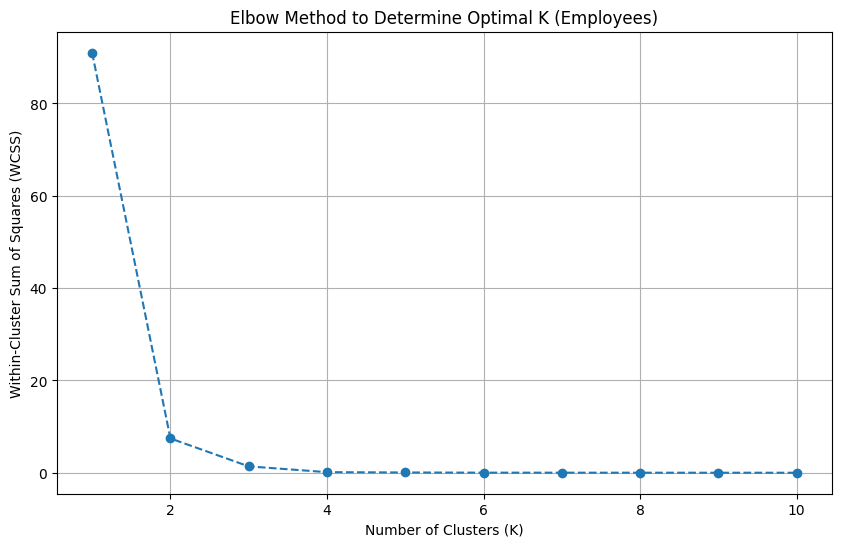

Based on the elbow plot, 3 clusters appears to be a reasonable choice.


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Assume df["Employees"] has already been cleaned into integers
# Scale the data (important for KMeans)
from sklearn.preprocessing import StandardScaler

specified_n_clusters = 3 # Define this variable early

scaler = StandardScaler()
# Use plot_df which has its 'Employees' column cleaned and without NaNs
scaled_employees = scaler.fit_transform(plot_df[["Employees"]])

# Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_employees)
    wcss.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal K (Employees)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

# Choose optimal clusters (example: 3)
n_clusters = 3
print(f"Based on the elbow plot, {n_clusters} clusters appears to be a reasonable choice.")

# Perform KMeans with the chosen number of clusters and add cluster labels to plot_df
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
plot_df['Cluster'] = kmeans.fit_predict(scaled_employees)

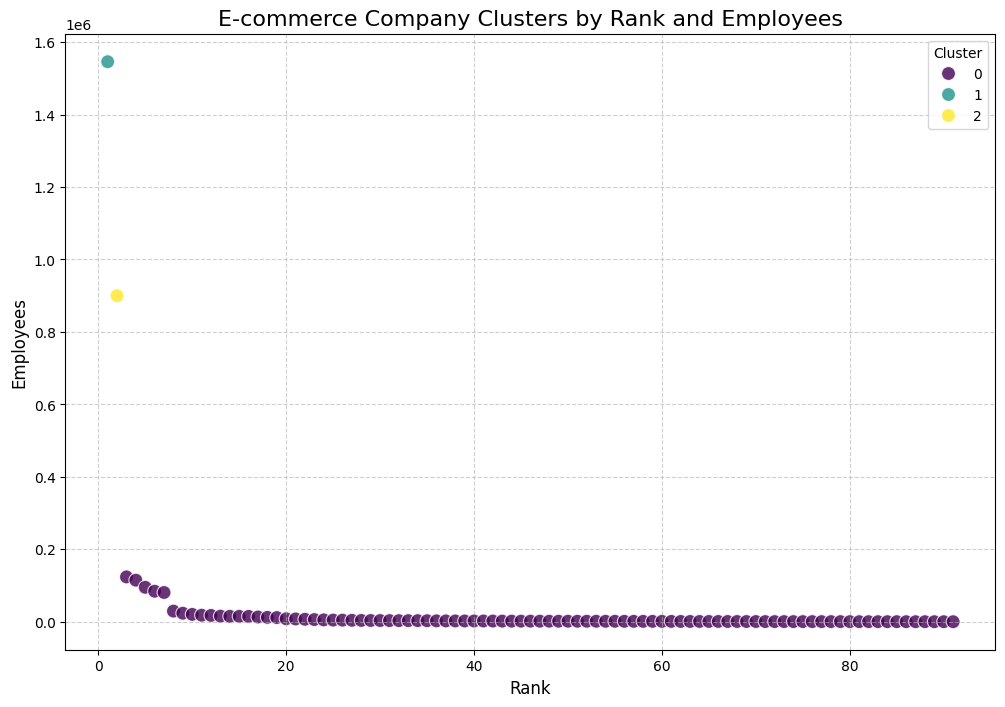

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize clusters using Rank vs Employees
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=plot_df, # Changed from df to plot_df
    x='Rank',
    y='Employees',
    hue='Cluster',
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('E-commerce Company Clusters by Rank and Employees', fontsize=16)
plt.xlabel('Rank', fontsize=12)
plt.ylabel('Employees', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Hierarchical Clustering

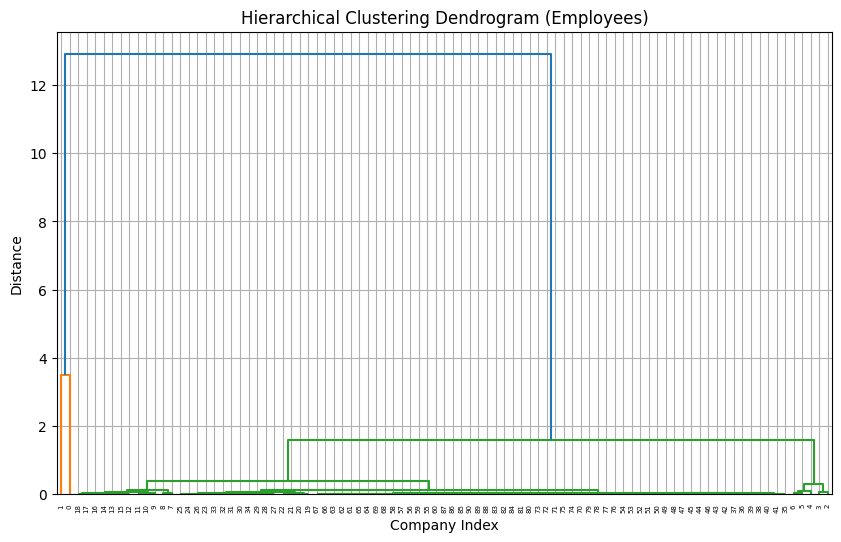

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Recreate df and its dependencies for robustness
url = "https://companiesmarketcap.com/e-commerce/largest-e-commerce-companies-by-number-of-employees/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

rows = soup.find_all("tr")
data = []

for row in rows[1:]:   # skip header
    cols = row.find_all("td")
    # Based on inspection of the page structure for employee data:
    # cols[0] is often an empty <td>
    # cols[1] contains the rank
    # cols[2] contains the company name
    # cols[3] contains the employee count
    if len(cols) >= 4:  # Ensure there are enough columns to access indices 1, 2, and 3
        rank = cols[1].text.strip()
        company = cols[2].text.strip()
        employees_count = cols[3].text.strip()
        data.append([rank, company, employees_count])

df = pd.DataFrame(data, columns=['Rank', 'Company', 'Employees'])


plot_df = df.copy()

# Clean and convert 'Employees' column to numeric
plot_df['Employees'] = plot_df['Employees'].str.replace(',', '', regex=False)
plot_df['Employees'] = pd.to_numeric(plot_df['Employees'], errors='coerce')
plot_df.dropna(subset=['Employees'], inplace=True)
plot_df['Employees'] = plot_df['Employees'].astype(int)

#  Use Employees for clustering as Revenue is not available
# Make sure 'plot_df' exists and contains the 'Employees' column
X = plot_df[['Employees']].values   # .values ensures a NumPy array

# Standardize data
sampler = StandardScaler()
X_scaled = sampler.fit_transform(X)

# Ward linkage for hierarchical clustering
linked = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram (Employees)')
plt.xlabel('Company Index')
plt.ylabel('Distance')
plt.grid(True)
plt.show()

Supervised Learning

Logistic Regression

Accuracy: 0.9473684210526315
Confusion Matrix:
 [[17  0]
 [ 1  1]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97        17
           1       1.00      0.50      0.67         2

    accuracy                           0.95        19
   macro avg       0.97      0.75      0.82        19
weighted avg       0.95      0.95      0.94        19



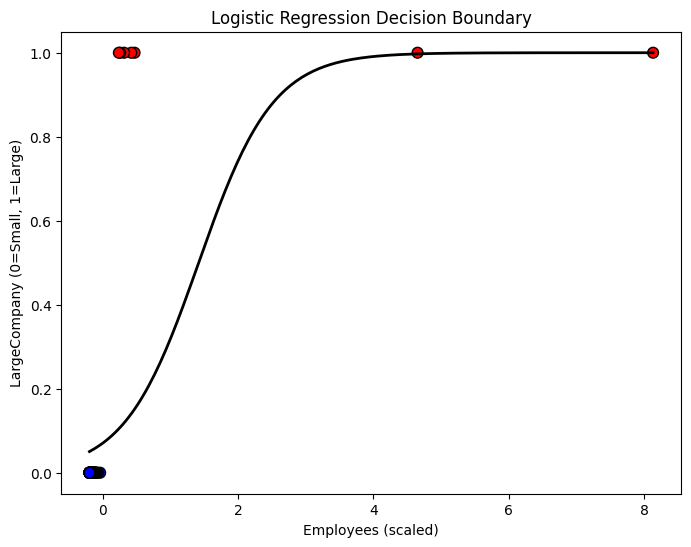

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# 1. Scrape data
# -------------------------------
url = "https://companiesmarketcap.com/e-commerce/largest-e-commerce-companies-by-number-of-employees/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

companies = []
employees = []

for row in soup.select("table tbody tr"): # Iterate over table rows
    cols = row.find_all("td")
    # Based on previous inspection, cols[2] is company name, cols[3] is employee count
    if len(cols) >= 4: # Ensure there are enough columns to access indices 2 and 3
        company = cols[2].get_text(strip=True) # Corrected index for company
        employee_count = cols[3].get_text(strip=True).replace(",", "") # Corrected index for employee count
        # Some employee counts might be 'N/A' or similar, handle conversion carefully
        try:
            employees.append(int(employee_count))
            companies.append(company)
        except ValueError:
            # Skip rows where employee count cannot be converted to int
            continue

df = pd.DataFrame({"Company": companies, "Employees": employees})

# -------------------------------
# 2. Create binary target variable
# -------------------------------
threshold = 50000   # classify companies as Large (1) or Small (0)
df["LargeCompany"] = (df["Employees"] > threshold).astype(int)

# -------------------------------
# 3. Prepare features and target
# -------------------------------
X = df[["Employees"]].values
y = df["LargeCompany"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -------------------------------
# 4. Train logistic regression
# -------------------------------
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# -------------------------------
# 5. Predictions & evaluation
# -------------------------------
y_pred = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# -------------------------------
# 6. Visualize decision boundary
# -------------------------------
plt.figure(figsize=(8,6))

# Scatter plot of companies
plt.scatter(X_scaled, y, c=y, cmap="bwr", edgecolor="k", s=60)
plt.xlabel("Employees (scaled)")
plt.ylabel("LargeCompany (0=Small, 1=Large)")
plt.title("Logistic Regression Decision Boundary")

# Decision boundary curve
x_vals = np.linspace(X_scaled.min(), X_scaled.max(), 200).reshape(-1,1)
y_probs = log_reg.predict_proba(x_vals)[:,1]
plt.plot(x_vals, y_probs, color="black", linewidth=2)

plt.show()


SVM

Accuracy: 0.9473684210526315
Confusion Matrix:
 [[17  0]
 [ 1  1]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97        17
           1       1.00      0.50      0.67         2

    accuracy                           0.95        19
   macro avg       0.97      0.75      0.82        19
weighted avg       0.95      0.95      0.94        19



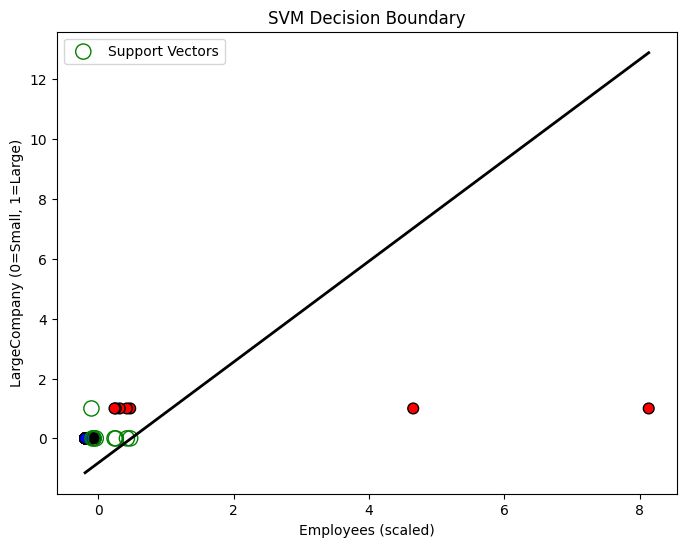

In [ ]:
# -------------------------------
# 1. Import libraries
# -------------------------------
import requests
from bs4 import BeautifulSoup
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

# -------------------------------
# 2. Scrape data
# -------------------------------
url = "https://companiesmarketcap.com/e-commerce/largest-e-commerce-companies-by-number-of-employees/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

companies = []
employees = []

for row in soup.select("table tbody tr"):
    cols = row.find_all("td")
    # Corrected indexing: cols[2] for company name, cols[3] for employee count
    if len(cols) >= 4:
        company = cols[2].get_text(strip=True)
        employee_count = cols[3].get_text(strip=True).replace(",", "")
        try:
            employees.append(int(employee_count))
            companies.append(company)
        except ValueError:
            # Skip rows where employee count cannot be converted to int (e.g., 'N/A')
            continue

df = pd.DataFrame({"Company": companies, "Employees": employees})

# -------------------------------
# 3. Create binary target
# -------------------------------
threshold = 50000
df["LargeCompany"] = (df["Employees"] > threshold).astype(int)

# -------------------------------
# 4. Prepare features and target
# -------------------------------
X = df[["Employees"]].values
y = df["LargeCompany"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# -------------------------------
# 5. Train SVM classifier
# -------------------------------
svm_clf = SVC(kernel="linear", probability=True)
svm_clf.fit(X_train, y_train)

# -------------------------------
# 6. Predictions & evaluation
# -------------------------------
y_pred = svm_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# -------------------------------
# 7. Visualize decision boundary
# -------------------------------
plt.figure(figsize=(8,6))

# Scatter plot of companies
plt.scatter(X_scaled, y, c=y, cmap="bwr", edgecolor="k", s=60)
plt.xlabel("Employees (scaled)")
plt.ylabel("LargeCompany (0=Small, 1=Large)")
plt.title("SVM Decision Boundary")

# Decision boundary line
x_vals = np.linspace(X_scaled.min(), X_scaled.max(), 200).reshape(-1,1)
y_decision = svm_clf.decision_function(x_vals)
plt.plot(x_vals, y_decision, color="black", linewidth=2)

# Support vectors
plt.scatter(svm_clf.support_vectors_, y[svm_clf.support_],
            s=120, facecolors='none', edgecolors='green', label="Support Vectors")

plt.legend()
plt.show()

Confusion Matrix

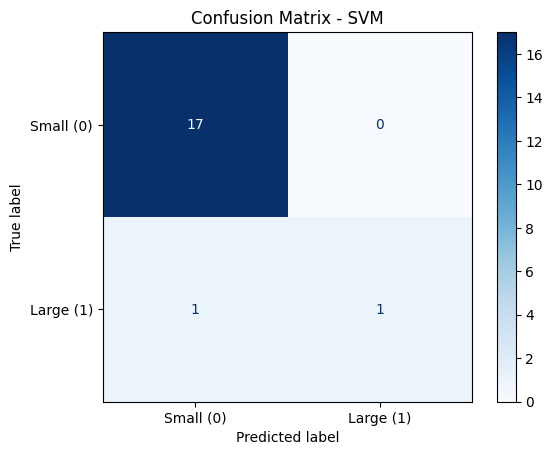

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        17
           1       1.00      0.50      0.67         2

    accuracy                           0.95        19
   macro avg       0.97      0.75      0.82        19
weighted avg       0.95      0.95      0.94        19



In [ ]:
# Import required libraries
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Train SVM model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# Make predictions
y_pred = svm_model.predict(X_test)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Small (0)", "Large (1)"])

disp.plot(cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.show()

# Print classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        84
           1       1.00      0.86      0.92         7

    accuracy                           0.99        91
   macro avg       0.99      0.93      0.96        91
weighted avg       0.99      0.99      0.99        91



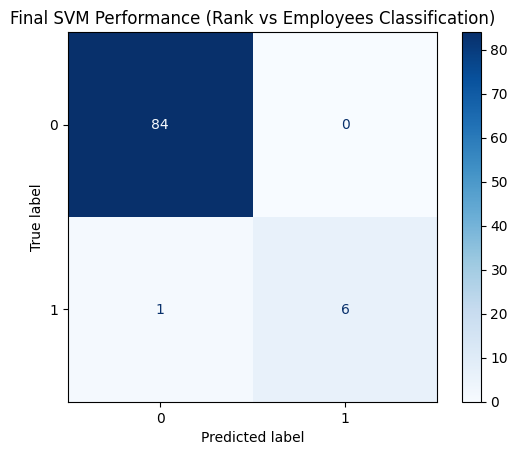

In [ ]:
import pandas as pd
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plotting

# --- STEP 1: Formatting ---
pd.options.display.float_format = '{:,.2f}'.format

# --- STEP 2: Data Preparation (Re-scrape and clean for robustness) ---
# Scrape data again to ensure 'Rank' and 'Employees' are available in df
url = "https://companiesmarketcap.com/e-commerce/largest-e-commerce-companies-by-number-of-employees/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

companies_data = []
for row in soup.select("table tbody tr"):
    cols = row.find_all("td")
    # Ensure there are enough columns and extract data correctly
    if len(cols) >= 4:
        rank = cols[1].text.strip()
        company = cols[2].text.strip()
        employees_count_str = cols[3].get_text(strip=True).replace(",", "")
        try:
            employees_count = int(employees_count_str)
            companies_data.append([rank, company, employees_count])
        except ValueError:
            continue # Skip rows where employee count cannot be converted

df = pd.DataFrame(companies_data, columns=['Rank', 'Company', 'Employees'])

# Ensure Rank and Employees are numeric
df['Rank'] = pd.to_numeric(df['Rank'], errors='coerce')
df['Employees'] = pd.to_numeric(df['Employees'], errors='coerce')
df.dropna(subset=['Rank', 'Employees'], inplace=True) # Drop rows with NaNs in these critical columns
df['Rank'] = df['Rank'].astype(int)
df['Employees'] = df['Employees'].astype(int)

# --- STEP 3: SVM Classification ---
# Create a label (using the same threshold as previous examples for consistency: 50000 employees)
threshold = 50000
df['IsLarge'] = (df['Employees'] > threshold).astype(int)

# Use 'Rank' and 'Employees' as features for the SVM model
X = df[['Rank', 'Employees']].values
y = df['IsLarge'].values

# Scaling is mandatory for SVM!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = svm.SVC(kernel='linear', C=1.0)
model.fit(X_scaled, y)

# --- STEP 4: Results ---
y_pred = model.predict(X_scaled)
print(classification_report(y, y_pred))

# Visualizing the Confusion Matrix
ConfusionMatrixDisplay.from_estimator(model, X_scaled, y, cmap='Blues')
plt.title("Final SVM Performance (Rank vs Employees Classification)")
plt.show()

EDA Analysis

In [ ]:
import pandas as pd
import numpy as np

# Load Dataset (using existing df from web scraping)
# df = pd.read_csv("your_dataset.csv")   # Original line: change filename
# Using the df populated from previous web scraping steps

# Ensure df is properly set up if this cell is run independently or out of order
# This assumes df is already available and cleaned from previous execution, e.g., cell WQI0kSR-hop5
# For robustness, if df might not be available, uncomment and adapt the scraping code:
# import requests
# from bs4 import BeautifulSoup

# url = "https://companiesmarketcap.com/e-commerce/largest-e-commerce-companies-by-number-of-employees/"
# response = requests.get(url)
# soup = BeautifulSoup(response.text, "html.parser")

# companies_data = []
# for row in soup.select("table tbody tr"):
#     cols = row.find_all("td")
#     if len(cols) >= 4:
#         rank = cols[1].text.strip()
#         company = cols[2].text.strip()
#         employees_count_str = cols[3].get_text(strip=True).replace(",", "")
#         try:
#             employees_count = int(employees_count_str)
#             companies_data.append([rank, company, employees_count])
#         except ValueError:
#             continue

# df = pd.DataFrame(companies_data, columns=['Rank', 'Company', 'Employees'])
# df['Rank'] = pd.to_numeric(df['Rank'], errors='coerce')
# df['Employees'] = pd.to_numeric(df['Employees'], errors='coerce')
# df.dropna(subset=['Rank', 'Employees'], inplace=True)
# df['Rank'] = df['Rank'].astype(int)
# df['Employees'] = df['Employees'].astype(int)


#  Basic Information
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

# First & Last 5 Rows
print("\nFirst 5 Rows:")
print(df.head())

print("\nLast 5 Rows:")
print(df.tail())

#  Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

#  Duplicate Values
print("\nDuplicate Rows:", df.duplicated().sum())

#  Summary Statistics
print("\nDescriptive Statistics:")
print(df.describe())

#  Correlation Matrix (Numerical Columns Only)
print("\nCorrelation Matrix:")
print(df.corr(numeric_only=True))

#  Unique Values (Categorical Columns)
print("\nUnique Values in Each Column:")
for col in df.columns:
    print(f"\n{col}:")
    print("Unique count:", df[col].nunique())

# Check Skewness
print("\nSkewness:")
print(df.skew(numeric_only=True))

# Check Value Counts (if classification column exists)
# Replace 'IsLarge' with your target column
if 'IsLarge' in df.columns:
    print("\nClass Distribution:")
    print(df['IsLarge'].value_counts())

Shape of dataset: (91, 4)

Columns:
Index(['Rank', 'Company', 'Employees', 'IsLarge'], dtype='object')

Data Types:
Rank          int64
Company      object
Employees     int64
IsLarge       int64
dtype: object

First 5 Rows:
   Rank         Company  Employees  IsLarge
0     1      AmazonAMZN    1546000        1
1     2        JD.comJD     900000        1
2     3     AlibabaBABA     123711        1
3     4  Meituan3690.HK     114731        1
4     5     CoupangCPNG      95000        1

Last 5 Rows:
    Rank             Company  Employees  IsLarge
86    87      CDON ABCDON.ST         66        0
87    88           UpexiUPXI         64        0
88    89  Treasure GlobalTGL         25        0
89    90           KidpikPIK         14        0
90    91   Jeffs' BrandsJFBR         10        0

Missing Values:
Rank         0
Company      0
Employees    0
IsLarge      0
dtype: int64

Duplicate Rows: 0

Descriptive Statistics:
       Rank    Employees  IsLarge
count 91.00        91.00    91.00
m

Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 0.01, 0.001],
    'kernel': ['linear', 'rbf']
}

# Create model
svm = SVC()

# Grid Search
grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Fit model
grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid.best_params_)

# Best model
best_model = grid.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00         2

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19

